# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [26]:
STUDENT_NAME = "Nguyễn Quốc Bảo"  # TODO: Họ và tên
STUDENT_ID = "2510029"    # TODO: MSSV


print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Quốc Bảo (2510029)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
# shifted_logits = ...
shifted_logits = logits - logits.max(axis =1,keepdims= True)
# exp_logits = ...
exp_logits = np.exp(shifted_logits)
# class_probabilities = ...
class_probabilities = exp_logits / exp_logits.sum(axis = 1, keepdims = True)
# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis = 1)
# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis =1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
# train_feature_mean = ...
train_feature_mean = X_train.mean(axis =0)
# train_feature_std = ...
train_feature_std = X_train.std(axis = 0)
# X_train_scaled = ...
X_train_scaled = (X_train - train_feature_mean)/train_feature_std
# X_val_scaled = ...
X_val_scaled = (X_val- train_feature_mean)/train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
# correct_mask = ...
correct_mask = (predicted_classes == true_labels)
# high_confidence_mask = ...
high_confidence_mask = (confidence_scores >= confidence_threshold)
# review_mask = ...
review_mask = (~correct_mask | ~high_confidence_mask)
# review_indices = ...
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
# normalized_batch = ...
normalized_batch = image_batch_uint8.astype(np.float32)/255.0
# augmented_batch = ...
augmented_batch = normalized_batch[:,:,::-1,:].copy()
# augmented_batch[0, 0, 0, 0] = ...
augmented_batch[0,0,0,0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1. mỗi dòng đại diện cho một mẫu xe ô tô cụ thể bao gồm nhiều feature như: giá bán, bảo hiểm, mã lực,..
2. Ký hiệu missing value trong csv là NaN /'?'
3. symboling là chỉ số rủi ro bảo hiểm đánh giá mức độ rủi ro của một chiếc xe trong khoảng [-3,3]

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
# raw_df = ...
raw_df = pd.read_csv('data/automobile_raw.csv')
# raw_shape = ...
raw_shape = raw_df.shape
# raw_missing_marker_count = ...
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
# df_clean = ...
df_clean = raw_df.replace('?', np.nan)
# for column in NUMERIC_COLUMNS:
#     ...
for column in NUMERIC_COLUMNS:
    df_clean[column]= pd.to_numeric(df_clean[column])
# missing_by_column = ...
missing_by_column = df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
4. khi ta fill tát cả numeric columns bằng cùng một giá trị thì tất cả feature sẽ có số liệu là như nhau, mà như vậy hoàn toàn sai bởi một feature có một số liệu tường ứng, không thể giống nhau ví dụ thông số mã lực và giá tiền không thể cùng một giá trị
5. Với Price thì ta nên drop hay xóa mẫu thiếu dữ liệu price. Bởi price là biến phụ thuộc- thứ chúng ta cần phân tích nguyên nhân hay xây dựng mô hình dự đoán. Khi ta fill giá trị này thì sẽ gẫy ra sai số lớn cho mô hình.
6. normalized_losses thiếu nhiều dữ liệu hơn các cột khác. Nếu ta drop dòng thì sẽ mất toàn bộ dữ liệu của toàn bộ mẫu đó. Còn nếu ta fill bằng median/ mean thì số liệu của normalized_losses sẽ tập trung ở median/mean làm sai lệch độ phân tán của dữ liệu.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
# analysis_df = ...
analysis_df = df_clean[AUTO_FEATURES].dropna()
# X_auto = ...
X_auto = analysis_df.to_numpy().astype(np.float64)
# auto_feature_mean = ...
auto_feature_mean = X_auto.mean(axis =0)
# auto_feature_std = ...
auto_feature_std = X_auto.std(axis =0)
# X_auto_scaled = ...
X_auto_scaled = (X_auto -auto_feature_mean)/auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
# price_index = ...
price_index = AUTO_FEATURES.index('price')
# price_z = ...
price_z = X_auto_scaled[:, price_index]
# price_outlier_mask = ...
price_oulier_mask = (np.abs(price_z) > 2)
# price_outliers = ...
price_outliers = analysis_df[price_oulier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
# engine_price_corr = ...
engine_idx = AUTO_FEATURES.index('engine_size')
price_idx = AUTO_FEATURES.index('price')
engine_mang = X_auto[:, engine_idx]
price_mang = X_auto[:, price_idx]
engine_price_corr = np.corrcoef(engine_mang, price_mang)[0,1]
# price_by_body_style = ...
price_by_body_style = (
    df_clean.groupby('body_style')['price'].mean().sort_index()
)

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

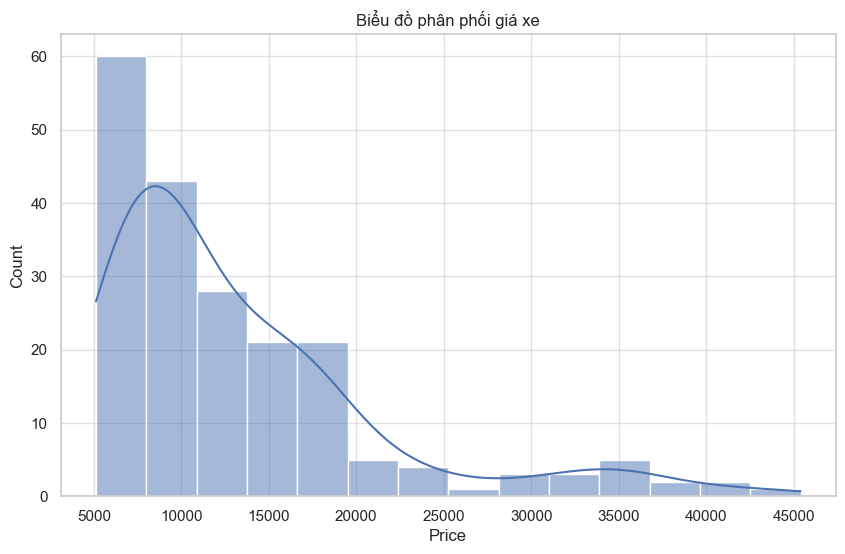

In [20]:
# TODO M2.1: histogram/KDE của price
fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(data = analysis_df, x= 'price', kde = True,ax= ax)
plt.title("Biểu đồ phân phối giá xe")
plt.xlabel("Price")
plt.ylabel("Count")
plt.grid(alpha =0.6)


**Nhận xét:** 
1. Biểu đồ lệch phải, có số lượng xe nhiều nhất ở những phân khúc thấp và giảm dần ở những phân khúc cao hơn
2. Biểu đồ có outlier ở những phân khúc xe giá cao

## M2.2 Dataset có cân bằng theo body style không?

Text(0, 0.5, 'count')

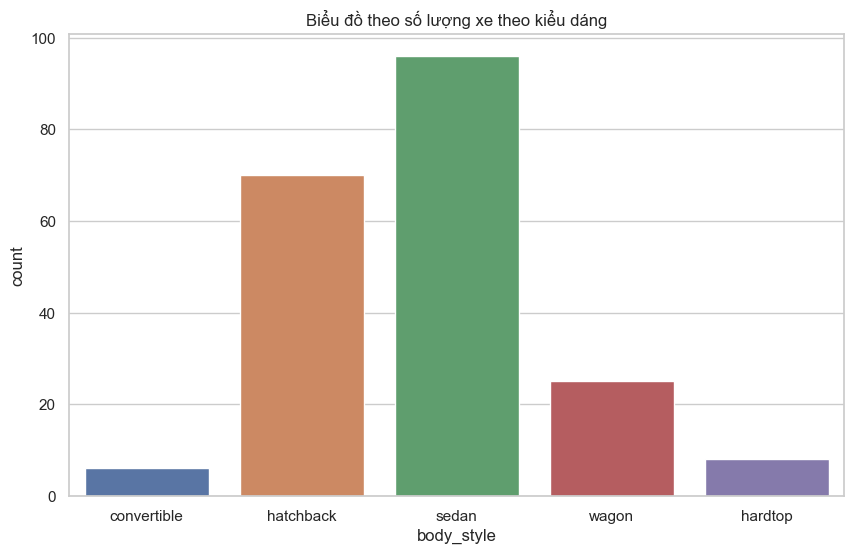

In [21]:
# TODO M2.2: countplot của body_style
fig, ax = plt.subplots(figsize = (10,6))
sns.countplot(data= df_clean, x = 'body_style', hue = 'body_style', ax = ax)
plt.title("Biểu đồ theo số lượng xe theo kiểu dáng")
plt.xlabel("body_style")
plt.ylabel("count")


**Nhận xét:** <!-- 1--2 câu -->
1. Biểu đồ không phân phối không đồng đêu, mất cân bằng giữa các kiểu dáng. 
2. Kiểu dáng sedan có số lượng xe nhiều nhất, ngược lại convertible và hardtop là ít nhất.

## M2.3 Price khác nhau theo body style ra sao?

Text(0, 0.5, 'price')

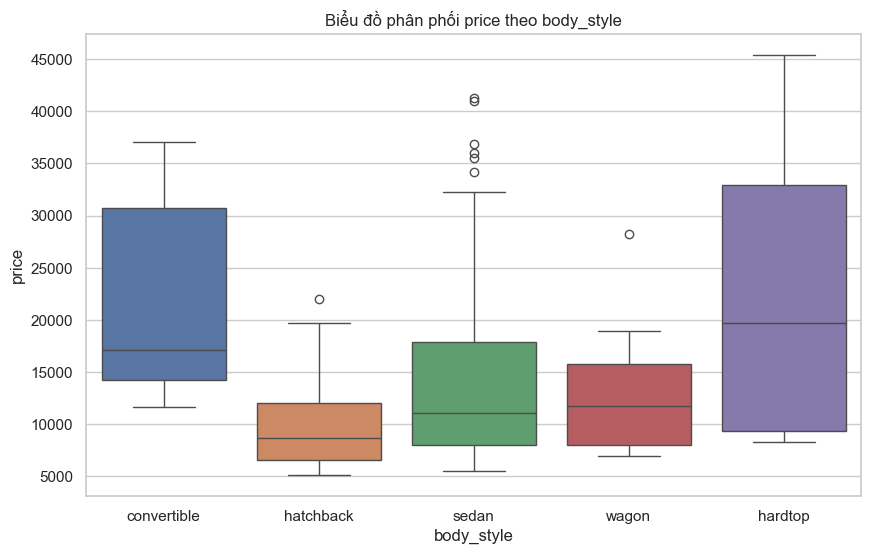

In [22]:
# TODO M2.3: boxplot price theo body_style
fig, ax = plt.subplots(figsize = (10,6))
sns.boxplot(data = df_clean ,x = 'body_style', y = 'price', hue = 'body_style', ax= ax);
plt.title("Biểu đồ phân phối price theo body_style")
plt.xlabel("body_style")
plt.ylabel("price")

**Nhận xét:** <!-- 1--2 câu -->
- Dòng xe convertible và hardtop có phân khúc giá cao nhất với trung vị dẫn đầu và có khoảng giá lớn
- Ngược lại dòng hatchback thì thuộc phân khúc giá thấp nhất và khoảng giá nhỏ. Đồng thời kiểu sedan tuy thuộc phân khúc tầm trung như có nhiểu điểm outlier lên tới trên 300000.

## M2.4 Engine size liên quan thế nào tới price?

Text(0, 0.5, 'price')

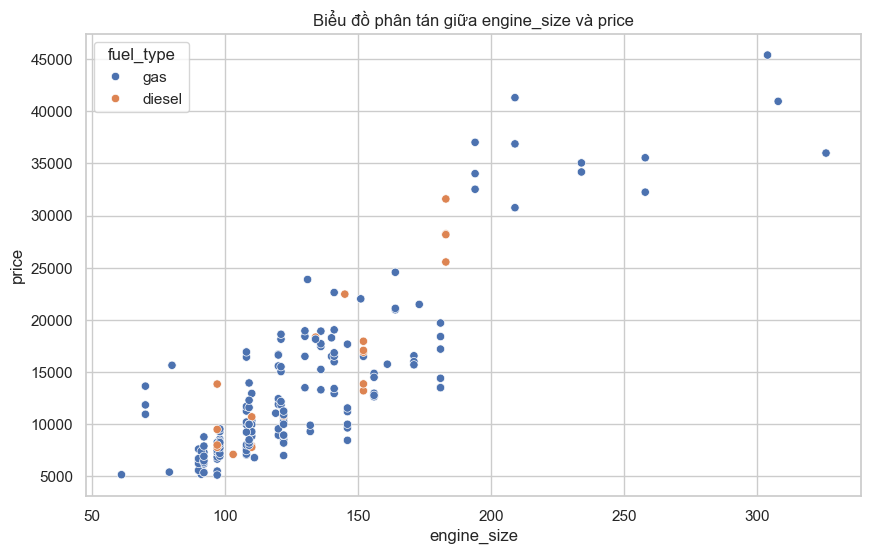

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
fig, ax = plt.subplots(figsize = (10,6))
sns.scatterplot(data = df_clean ,x = 'engine_size', y = 'price', hue = 'fuel_type', ax= ax);
plt.title("Biểu đồ phân tán giữa engine_size và price")
plt.xlabel("engine_size")
plt.ylabel("price")


**Nhận xét:** <!-- 1--2 câu -->
- Với loại nhiên liệu là diesel biểu đồ có mật độ phân tán và dày đặc nhất tập trung ở phân khúc [5000,20000] và engine_size khoảng [50,200], thưa dần về góc phải đồ thị
- Ngược lại gas có mật độ phân tán thấp, thưa.

## M2.5 Các feature numeric tương quan ra sao?

Text(0.5, 1.0, 'Biểu đồ tương quan ')

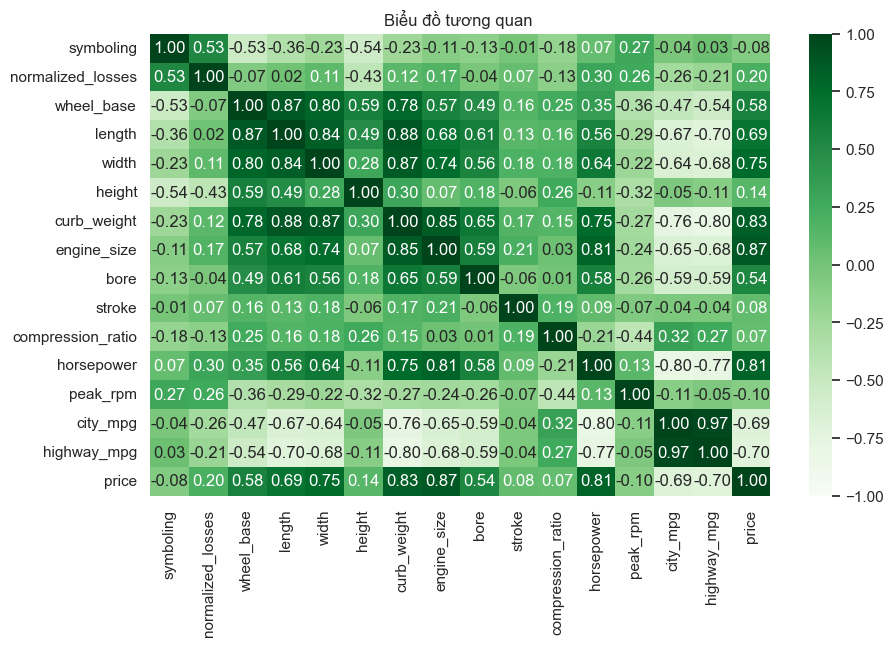

In [24]:
# TODO M2.5: correlation heatmap
correlation = df_clean.corr(numeric_only = True)
fig, ax = plt.subplots(figsize = (10,6))
sns.heatmap(data = correlation , annot = True, fmt = ".2f",cmap = "Greens",vmin =-1, vmax = 1 , ax= ax)
plt.title("Biểu đồ tương quan ")

**Nhận xét:** <!-- 1--2 câu -->
- Tương quan mạnh: các feature như horsepower, curb_engine, engine_size tương quan mạnh với price. Nghĩa là khi các đặc điểm này có số liệu càng lớn thì giá càng cao.
- Tương quan yếu: các feature như city_mpg và highway_mpg có tương quan rất yếu với price lần lượt là -0.69 và -0.7. Có ý nghĩa là khi xe càng tiết kiệm nhiên liệu thì giá xe càng rẻ.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

Text(0, 0.5, 'price')

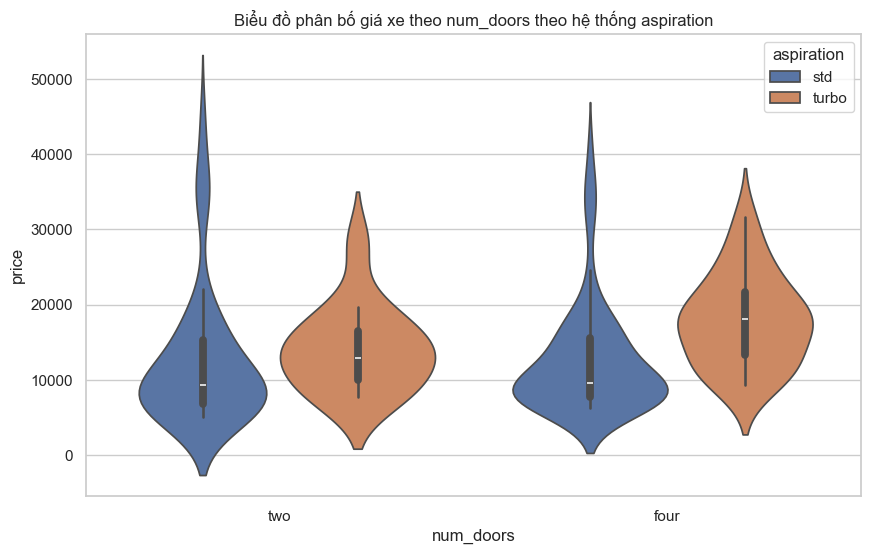

In [25]:
# TODO M2.6: biểu đồ tự chọn
fig,ax = plt.subplots(figsize = (10,6))
sns.violinplot(data = df_clean, x = 'num_doors', y ='price' , hue = 'aspiration')
plt.title("Biểu đồ phân bố giá xe theo num_doors theo hệ thống aspiration")
plt.xlabel("num_doors")
plt.ylabel("price")

**Nhận xét:** <!-- 1--2 câu -->
- Về mức giá trung bình: dù là loại 4 cửa hay 2 cửa thì loại turbo có giá trung bình cao hơn loại std 
- Về phân bố và hình dạng: loại std tập trung ở phân khúc giá thấp và khoảng biên độ trải dài, outlier lên tới 500000 ở xe 2 cửa. Ngược lại,Turbo tập trung ở phân khúc giá cao hơn, biên độ phân bố đồng đều hơn ở cả loại 2 cửa và 4 cửa

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->
1. Đánh giá tổng quan
- Các loại xe tập trung chủ yếu ở phân khúc bình dân, Biểu đồ lệch phải theo giá xe nằm trong khoảng 50000-150000 (biểu đồ 1)
- Kiểu dáng sedan và hatchback có số lượng xe chiếm nhiều nhất, tuy nhiên hardtop hiếm nhất nhưng lại có giá trung vị cao nhất và phổ giá rộng nhất (biểu đồ 2 và 3)
- Kích thược động cơ ảnh hưởng lớn đến giá xe, động cơ càng lớn kích thước càng cao (biểu đồ 4 và 5)
- Hệ thống Turbo nâng giá trị của xe, dù là xe 2 cửa hay 4 cửa thì xe có động cơ là turbo có giá cao hơn (biểu đồ 6)
2. Hạn chế của dataset
- Phân bố dữ liệu không đồng đều: dataset có những mẫu xe có số lượng nhiều hơn các mẫu còn lại (ví dụ xe xăng và sedan/hatchback nhiều, trong khi khi các mẫu khác thì ít)
- Thiếu các mẫu xe phân khúc giá cao: đa số các xe giá cao xuất hiện ở dạng outlier, khó thể hiện chính xác cho mẫu xe hạng sang.
3. Ví dụ về correlation không đồng nghĩa causation
- Heatmap cho thấy city_mpg tương quan nghịch mạnh với price (-0.69). Tuy nhiên, không thể kết luận chế tạo xe hao xăng hơn sẽ giúp bán được giá cao hơn. Thực tế, xe giá cao thường đi kèm động cơ lớn (engine_size) và khối lượng nặng (curb_weight), và chính những yếu tố vật lý này mới là nguyên nhân trực tiếp làm giảm hiệu suất nhiên liệu (MPG thấp).
4. Câu hỏi nên phân tích tiếp là
- Nếu có feature brand thì nó sẽ ảnh hướng đến giá xe như thế nào?